### 3d cavity caclulation

In [ ]:
def inch_to_meter(n):
    return n * 0.0254

x = inch_to_meter(1+12/32)
y = round(inch_to_meter(6/32),7)
z = inch_to_meter(22/32 * 2)

c_ = (2.99792458 * 10 **8)/2
def calc_f_TE(a,b,d,m,n,p):
    x_part = (m/a)**2
    y_part = (n/b)**2
    z_part = (p/d)**2
    return c_ * (x_part+y_part+z_part)**0.5

#calc_f_TE(x,y,z,1,0,1) * 10 **(-9)


#it doesn't matter where x and z go since they are the same value
#if y is not in the center where the n value is 0 then the value is very large
calc_f_TE(x,y,z,1,0,1) * 10 **(-9)

# Real Code

In [258]:
%matplotlib inline

In [259]:
import logging

# qcodes imports
from qcodes.dataset import (
    Measurement,
    load_experiment_by_name,
    new_experiment,
    plot_by_id,
)
from qcodes.instrument_drivers.Keysight import KeysightN5245A

# setup
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)

# Start experiment
exp_name = "Cavity"
sample_name = "Thru_Coax"

try:
    exp = load_experiment_by_name(exp_name, sample = sample_name)
    print("Experiment loaded. Last ID no:", exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print("Starting new experiment.")

Experiment loaded. Last ID no: 26


In [261]:
pne = KeysightN5245A("pne", "USB0::0x2A8D::0x0001::MY55100528::INSTR")

Connected to: Keysight Technologies E5080A (serial:MY55100528, firmware:A.12.60.03) in 0.12s


In [62]:
import matplotlib.pyplot as plt
from qcodes.dataset import plot_dataset

Starting experimental run with id: 28. 


([<Axes: title={'center': 'Run #28, Experiment Cavity (Thru_Coax)'}, xlabel='Frequency (GHz)', ylabel='Magnitude (dB)'>],
 [None])

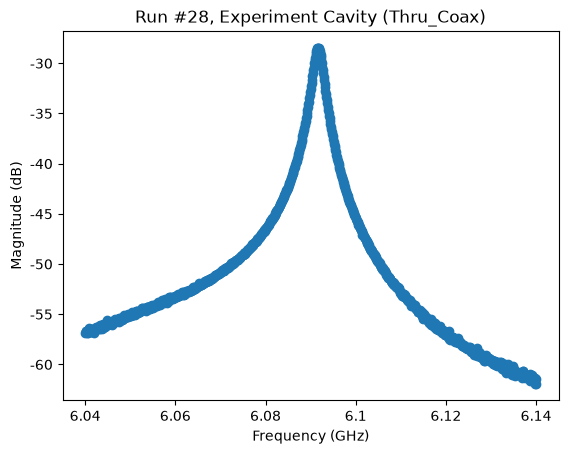

In [264]:
# Set up a frequency sweep from 100 MHz to 1 GHz, with 1001 points, at a power of -40dBm
pne.power(-30)
pne.start(6.04e9)
pne.stop(6.14e9)
pne.points(1001)
pne.trace("S21")

# Enable 2 averages, and set IF BW to 1kHz
pne.if_bandwidth(1e3)
pne.averages_enabled(True)
pne.averages(10)

# Run a measurement
meas = Measurement()
meas.register_parameter(pne.magnitude)

with meas.run() as datasaver:
    mag = pne.magnitude()
    datasaver.add_result((pne.magnitude, mag))
    dataid = datasaver.run_id
plot_by_id(dataid)

In [269]:
meas_dataset = datasaver.dataset
meas_dataset.export(export_type="csv", path="/Users/bordeim1/Desktop/python/")


Starting experimental run with id: 31. 


([<Axes: title={'center': 'Run #31, Experiment Cavity (Thru_Coax)'}, xlabel='Frequency (GHz)', ylabel='Real ($10^{-3}$ LinMag)'>,
  <Axes: title={'center': 'Run #31, Experiment Cavity (Thru_Coax)'}, xlabel='Frequency (GHz)', ylabel='Imaginary ($10^{-3}$ LinMag)'>],
 [None, None])

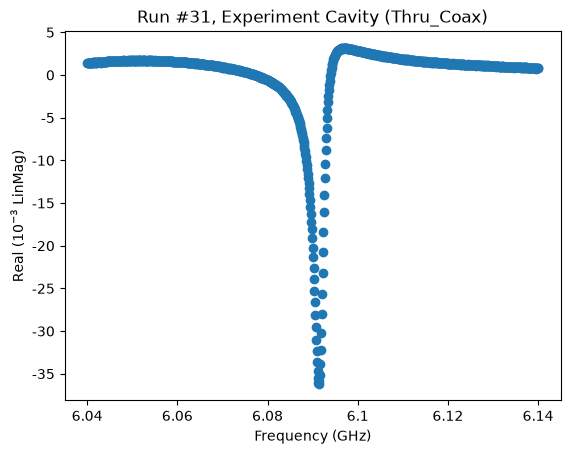

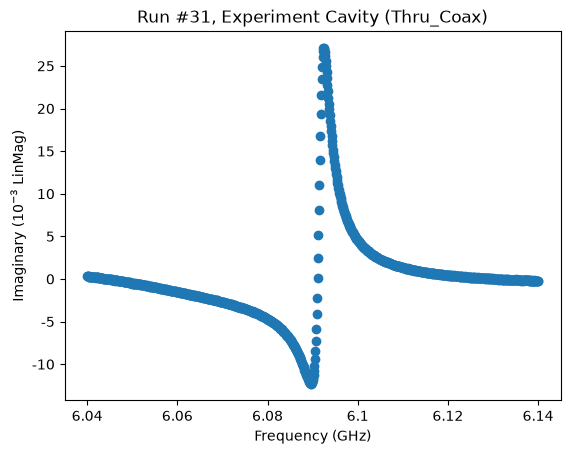

In [ ]:
pne.auto_sweep(False)
meas = Measurement()
meas.register_parameter(pne.real)
meas.register_parameter(pne.imaginary)

with meas.run() as datasaver:
    pne.traces.tr1.run_sweep()
    real = pne.real()
    img = pne.imaginary()
    datasaver.add_result((pne.real, real), (pne.imaginary, img))
    dataid = datasaver.run_id
plot_by_id(dataid)

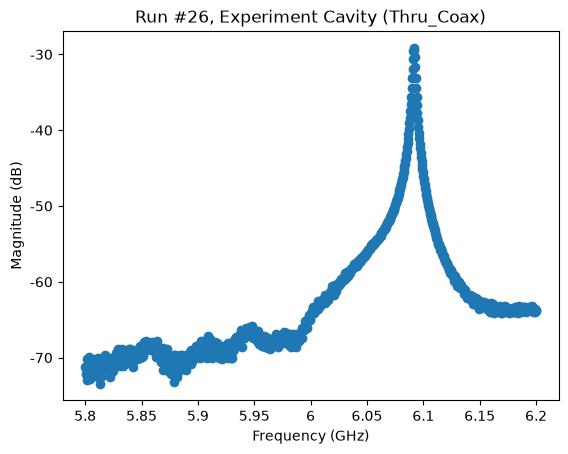

In [64]:
axes, colorbars = plot_by_id(dataid)
fig = axes[0].figure
fig.savefig(f"qcodes_cavity_expirement.png")

In [ ]:
def S_21(f, Ql, Qc, fr):
    f_mhz = f / 1e6
    fr_mhz = fr / 1e6
    top = Ql/Qc
    bottom = 1+ 2j * Ql * (f_mhz/fr_mhz -1)
    return (1 - top/bottom)

def convert_S21_to_dB(f,Ql,Qc,fr):
    S = S_21(f,Ql,Qc,fr)
    linear = np.abs(S)
    return 20 * np.log10(linear)

def Real(f,Ql,Qc,fr):
    R = 2j *Ql * (f/fr - 1)
    return (-R**2 - Ql/Qc + 1)/(1-R**2)

def Complex(f,Ql,Qc,fr):
    R = 2j *Ql * (f/fr - 1)
    return (2j * Ql**2/Qc * (f/fr - 1))/(1-R**2)



In [304]:
print(S_21_other(1*10**4,6*10**3,5*10**4,6*10**4))
print((S_21(1*10**4,6*10**3,5*10**4,6*10**4)))
print((Real(1*10**4,6*10**3,5*10**4,6*10**4) + Complex(1*10**4,6*10**3,5*10**4,6*10**4)))
print(np.abs(Real(1*10**4,6*10**3,5*10**4,6*10**4) + Complex(1*10**4,6*10**3,5*10**4,6*10**4)))


1.1999999940000001e-05
(0.9999999988-1.1999999880000002e-05j)
(0.9999999988-1.199999988e-05j)
0.999999998872


1.1999999940000001e-05


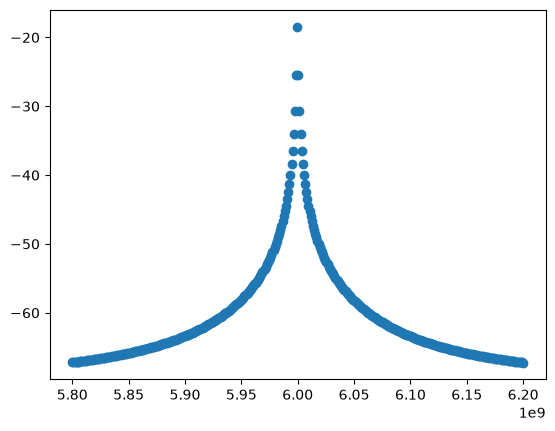

In [309]:
def S_21_other(f, Ql, Qc, fr):
    f_mhz = f / 1e6
    fr_mhz = fr / 1e6
    top = Ql/Qc
    bottom = 1+ 2j * Ql * (f_mhz/fr_mhz -1)
    return np.abs(top/bottom)

def convert_S21_to_dB(f,Ql,Qc,fr,baseline_dB):
    S = S_21(f,Ql,Qc,fr)
    linear = np.abs(S)
    baseline_linear = 10**(baseline_dB/20)
    total_linear = np.sqrt(linear**2 + baseline_linear**2)
    return 20 * np.log10(total_linear)


def convert_S21_other_to_dB(f,Ql,Qc,fr,baseline_dB):
    S = S_21_other(f,Ql,Qc,fr)
    baseline_linear = 10 ** (baseline_dB / 20)
    total_linear = np.sqrt(S**2 + baseline_linear**2)
    converted =  20 * np.log10(total_linear)
    return converted

def other_convert_S21_other_to_dB(f,Ql,Qc,fr,baseline_dB):
    S = S_21_other(f,Ql,Qc,fr)
    converted =  20 * np.log10(S)
    return converted + baseline_dB

# print((S_21(1***4,6*10**3,5*10**4,6*10**4)))
print(S_21_other(1*10**4,6*10**3,5*10**4,6*10**4))

#print(convert_S21_to_dB(1*10**4,6*10**3,5*10**4,6*10**4,-70))
#print(convert_S21_other_to_dB(1*10**4,6*10**3,5*10**4,6*10**4,-70))
# #S_21_other(5*10**4,6*10**3,5*10**4,6*10**4)
a = []
for i in np.arange(5.8,6.2+0.001,0.001):
    a.append(convert_S21_other_to_dB(i*10**4,6*10**3,5*10**4,6*10**4,-70))
plt.scatter(np.linspace(5.8e9, 6.2e9, len(a)),a)

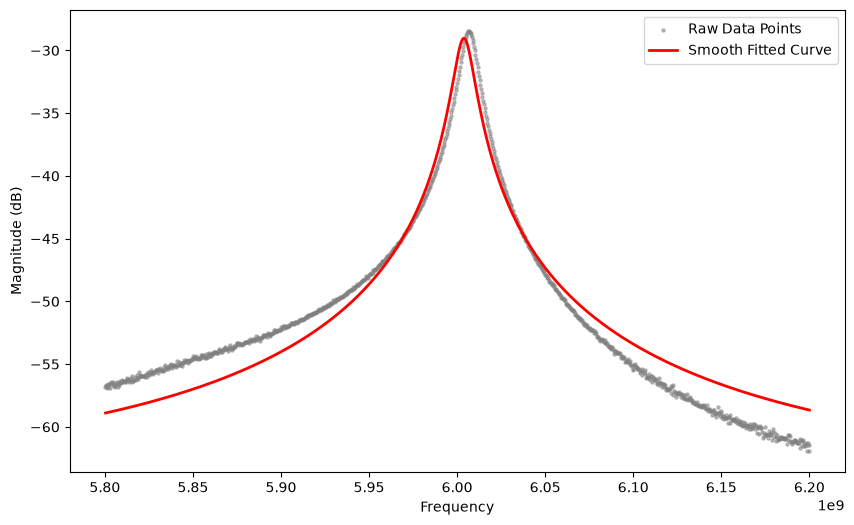

In [365]:
from scipy.optimize import curve_fit
#range from 5.8 to 6.2 GHz with 1001 points
x_data = np.linspace(5.8e9, 6.2e9, 1001)
y_data = np.array(mag[:1001])

guess_Ql = 2*10**3.0
guess_Qc = 5*10**4.0
peak_index = np.argmax(y_data)  
guess_fr = x_data[peak_index]
guess_baseline = -70
p0_guesses = [guess_Ql, guess_Qc, guess_fr, guess_baseline] 

popt, _ = curve_fit(convert_S21_other_to_dB, x_data, y_data, p0=p0_guesses)
optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline = popt

x_curve = np.linspace(x_data[1], x_data[-1], 5000)
y_curve = convert_S21_other_to_dB(x_curve, optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline)


plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='gray', alpha=0.5, s=5, label='Raw Data Points')
plt.plot(x_curve, y_curve, color='red', linewidth=2, label='Smooth Fitted Curve')
plt.xlabel('Frequency')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.show()

In [ ]:
import pandas as pd

# # Load the CSV file into a DataFrame
df = pd.read_csv('qcodes_cavity_test_fr_at_6GHz_range=5.8-6.2GHz.csv',  sep='\t', header=None)
mag = df[1]

In [231]:
popt

array([ 1.88097782e+03,  6.21027699e+04,  6.09083147e+09, -7.26905904e+01])

In [232]:
optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline

(1880.9778241593276, 62102.76991155487, 6090831470.085122, -72.69059039031677)

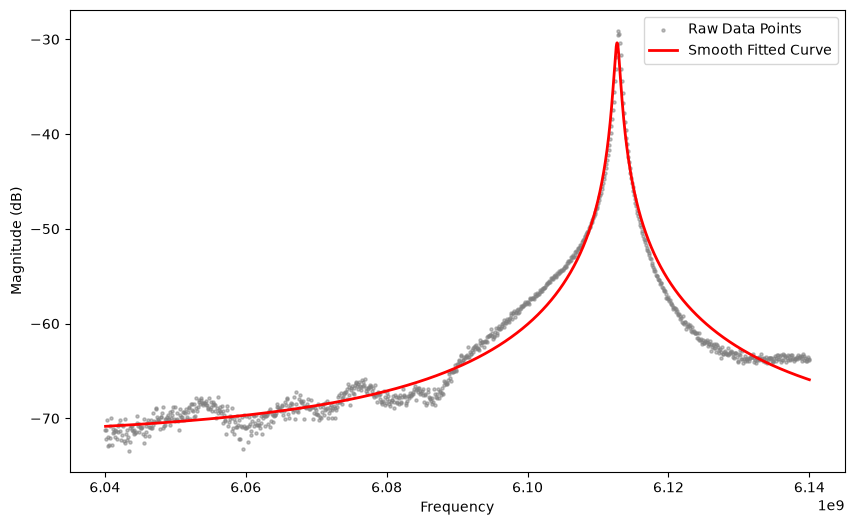

In [ ]:
from scipy.optimize import curve_fit
x_data = np.linspace(6.04e9, 6.14e9, 1001)
y_data = np.array(mag[:1001])

guess_Ql = 2*10**3.0
guess_Qc = 5*10**4.0
peak_index = np.argmax(y_data)  
guess_fr = x_data[peak_index]
guess_baseline = -70
p0_guesses = [guess_Ql, guess_Qc, guess_fr, guess_baseline] 

popt, _ = curve_fit(convert_S21_other_to_dB, x_data, y_data, p0=p0_guesses)
optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline = popt

x_curve = np.linspace(x_data[1], x_data[-1], 5000)
y_curve = convert_S21_other_to_dB(x_curve, optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline)


plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='gray', alpha=0.5, s=5, label='Raw Data Points')
plt.plot(x_curve, y_curve, color='red', linewidth=2, label='Smooth Fitted Curve')
plt.xlabel('Frequency')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

In [256]:
optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline

(2198.5907959257775, 66389.8744208643, 6090623157.696524, -65.8450287686133)

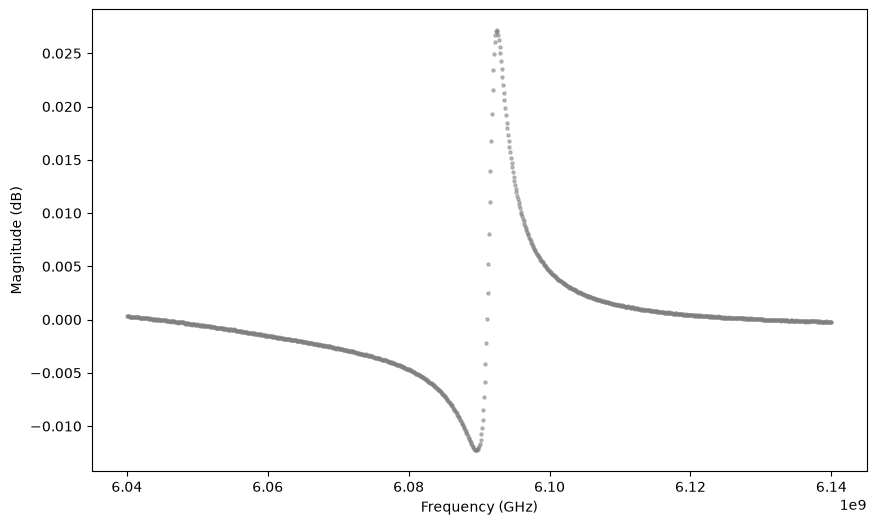

In [ ]:
x_data = np.linspace(6.04e9, 6.14e9, 1001)
y_data = np.array(img[:1001])

# def Complex_other(f,Ql,Qc,fr):
#     R = 2j *Ql * (f/fr - 1)
#     return np.abs(2j * Ql**2/Qc * (f/fr - 1))/(1-R**2).real


# guess_Ql = 2*10**3.0
# guess_Qc = 5*10**4.0
# peak_index = np.argmax(y_data)  
# guess_fr = x_data[peak_index]
# p0_guesses = [guess_Ql, guess_Qc, guess_fr] 

# popt, _ = curve_fit(Complex_other, x_data, y_data, p0=p0_guesses)
# optimal_Ql, optimal_Qc, optimal_fr = popt

# x_curve = np.linspace(x_data[1], x_data[-1], 5000)
# y_curve = Complex_other(x_curve, optimal_Ql, optimal_Qc, optimal_fr)

# plt.figure(figsize=(10, 6))
# plt.scatter(x_data, y_data, color='gray', alpha=0.5, s=5, label='Raw Data Points')
# plt.plot(x_curve, y_curve, color='red', linewidth=2, label='Smooth Fitted Curve')
# plt.xlabel('Frequency')
# plt.ylabel('Magnitude (dB)')
# plt.legend()
# plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='gray', alpha=0.5, s=5, label='Raw Data Points')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')


In [349]:
Real(1*10**4,6*10**3,5*10**4,6*10**4).real

0.9999999988

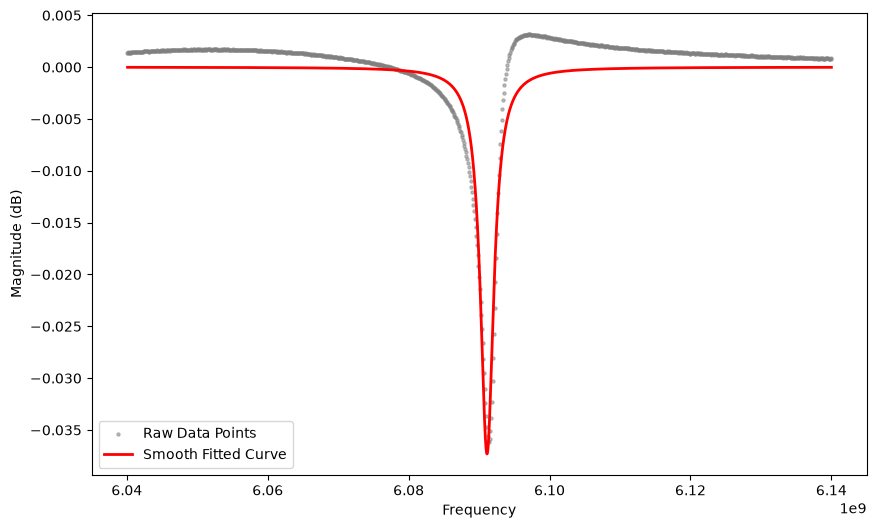

In [ ]:
x_data = np.linspace(6.04e9, 6.14e9, 1001)
y_data = np.array(real[:1001])


def Real_other(f,Ql,Qc,fr):
    d = (f/fr - 1)
    top = 4 * (Ql ** 2) * (d**2) -Ql/Qc +1
    bottom = 1 + 4*(Ql**2) * (d**2)
    linear = top/bottom
    return 10 * np.log10(linear) 
    

guess_Ql = 2*10**3.0
guess_Qc = 5*10**4.0
peak_index = np.argmin(y_data)  
guess_fr = x_data[peak_index]
p0_guesses = [guess_Ql, guess_Qc, guess_fr] 

popt, _ = curve_fit(Real_other, x_data, y_data, p0=p0_guesses)
optimal_Ql, optimal_Qc, optimal_fr = popt

x_curve = np.linspace(x_data[1], x_data[-1], 5000)
y_curve = Real_other(x_curve, optimal_Ql, optimal_Qc, optimal_fr)

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='gray', alpha=0.5, s=5, label='Raw Data Points')
plt.plot(x_curve, y_curve, color='red', linewidth=2, label='Smooth Fitted Curve')
plt.xlabel('Frequency')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.show()

Text(0, 0.5, 'Magnitude (dB)')

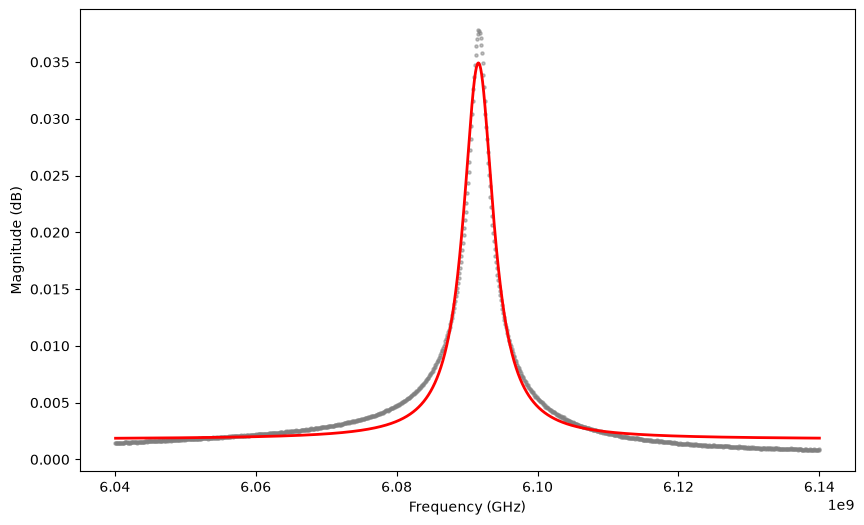

In [399]:
x_data = np.linspace(6.04e9, 6.14e9, 1001)
y_data = np.array(((real[:1001]**2 + img[:1001]**2)**0.5))

guess_Ql = 2*10**3.0
guess_Qc = 5*10**4.0
peak_index = np.argmax(y_data)  
guess_fr = x_data[peak_index]
guess_baseline = -50
p0_guesses = [guess_Ql, guess_Qc, guess_fr, guess_baseline] 

popt, _ = curve_fit(convert_S21_other_to_dB, x_data, y_data, p0=p0_guesses)
optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline = popt

x_curve = np.linspace(x_data[1], x_data[-1], 5000)
y_curve = convert_S21_other_to_dB(x_curve, optimal_Ql, optimal_Qc, optimal_fr, optimal_baseline)

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='gray', alpha=0.5, s=5, label='Raw Data Points')
plt.plot(x_curve, y_curve, color='red', linewidth=2, label='Smooth Fitted Curve')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')

In [ ]:
popt

array([-1.17835903e+03, -1.34621088e+04,  6.09160174e+09,  1.77984946e-03])

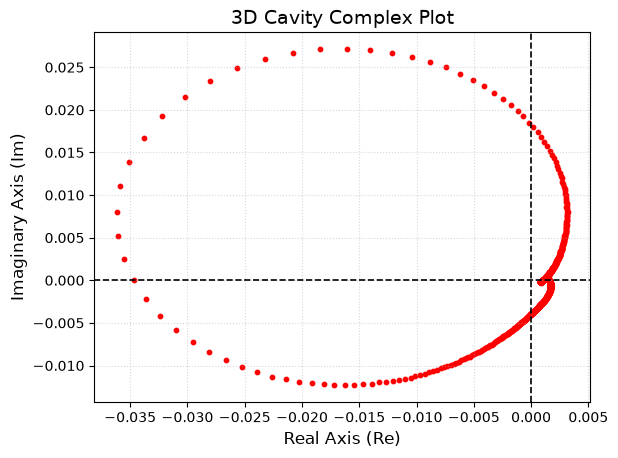

In [ ]:
complex_nums = real[:1001] + 1j*img[:1001]
x = [z.real for z in complex_nums]
y = [z.imag for z in complex_nums]
plt.scatter(x, y, color='red', marker='o', s=10, label='Complex Points')
plt.axhline(0, color='black', linewidth=1.2, linestyle='--') # Real axis
plt.axvline(0, color='black', linewidth=1.2, linestyle='--') # Imaginary axis
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.xlabel('Real Axis (Re)', fontsize=12)
plt.ylabel('Imaginary Axis (Im)', fontsize=12)
plt.title('3D Cavity Complex Plot', fontsize=14)
#plt.savefig('qcodes_cavity_real_and_img_on_complex_plane.png')